In [ ]:
import pandas as pd
import numpy as np

# Load dataset, skipping first 2 non-numeric header rows
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', skiprows=2)

# Initialize list to hold structured DSSC data
data_list = []

# Loop over every 2 columns (Voltage–Current pair)
for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        voltage = df_raw.iloc[:, i].dropna().astype(float)
        current = df_raw.iloc[:, i + 1].dropna().astype(float)
        sample_name = df_raw.columns[i].strip()

        if len(voltage) != len(current) or len(voltage) < 3:
            continue

        # Compute DSSC parameters
        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        # Extract dye name and ratio
        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        # Add to list
        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })
    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

# Create final DataFrame
df = pd.DataFrame(data_list)
print(f"✅ Loaded and processed {len(df)} DSSC samples.")
df.head()


Skipping columns 0-1 due to error: could not convert string to float: 'F -> R'
Skipping columns 2-3 due to error: could not convert string to float: 'F -> R'
Skipping columns 4-5 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 6-7 due to error: could not convert string to float: 'F -> R'
Skipping columns 8-9 due to error: could not convert string to float: 'F -> R'
Skipping columns 10-11 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 12-13 due to error: could not convert string to float: 'F -> R'
Skipping columns 14-15 due to error: could not convert string to float: 'F -> R'
Skipping columns 16-17 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 18-19 due to error: could not convert string to float: 'F -> R'
Skipping columns 20-21 due to error: could not convert string to float: 'F -> R'
Skipping columns 22-23 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 24-25 due to erro

""


In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', skiprows=2)

# Parse DSSC data
data_list = []

for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        voltage = df_raw.iloc[:, i].dropna().astype(float)
        current = df_raw.iloc[:, i + 1].dropna().astype(float)
        sample_name = df_raw.columns[i].strip()

        if len(voltage) != len(current) or len(voltage) < 3:
            continue

        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })
    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

# Create DataFrame
df = pd.DataFrame(data_list)

# Show the first few rows and confirm column names
print("✅ Successfully created structured DSSC DataFrame.")
print(df.columns)
df.head()


Skipping columns 0-1 due to error: could not convert string to float: 'F -> R'
Skipping columns 2-3 due to error: could not convert string to float: 'F -> R'
Skipping columns 4-5 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 6-7 due to error: could not convert string to float: 'F -> R'
Skipping columns 8-9 due to error: could not convert string to float: 'F -> R'
Skipping columns 10-11 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 12-13 due to error: could not convert string to float: 'F -> R'
Skipping columns 14-15 due to error: could not convert string to float: 'F -> R'
Skipping columns 16-17 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 18-19 due to error: could not convert string to float: 'F -> R'
Skipping columns 20-21 due to error: could not convert string to float: 'F -> R'
Skipping columns 22-23 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 24-25 due to erro

""


In [ ]:
import pandas as pd
import numpy as np

# Load dataset (skip headers with labels and units)
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', skiprows=2)

data_list = []

for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        voltage = df_raw.iloc[:, i].dropna().astype(float)
        current = df_raw.iloc[:, i + 1].dropna().astype(float)
        sample_name = df_raw.columns[i].strip()

        if len(voltage) != len(current) or len(voltage) < 3:
            continue

        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })
    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

df = pd.DataFrame(data_list)

# Display result
print("✅ DataFrame created with columns:", df.columns.tolist())
df.head()


Skipping columns 0-1 due to error: could not convert string to float: 'F -> R'
Skipping columns 2-3 due to error: could not convert string to float: 'F -> R'
Skipping columns 4-5 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 6-7 due to error: could not convert string to float: 'F -> R'
Skipping columns 8-9 due to error: could not convert string to float: 'F -> R'
Skipping columns 10-11 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 12-13 due to error: could not convert string to float: 'F -> R'
Skipping columns 14-15 due to error: could not convert string to float: 'F -> R'
Skipping columns 16-17 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 18-19 due to error: could not convert string to float: 'F -> R'
Skipping columns 20-21 due to error: could not convert string to float: 'F -> R'
Skipping columns 22-23 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 24-25 due to erro

""


In [ ]:
# View first few rows of the raw data
pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', nrows=10)


,A,Unnamed: 1,Unnamed: 2,B,Unnamed: 4,Unnamed: 5,K,Unnamed: 7,Unnamed: 8,M,...,Unnamed: 130,Unnamed: 131,AN-COV/CORR,Unnamed: 133,Unnamed: 134,BLANK,Unnamed: 136,Unnamed: 137,KM + CDCA (1:1 ratio),Unnamed: 139
0,Voltage (V),Current (A),NaN,Voltage (V),Current (A),NaN,Voltage (V),Current (A),NaN,Voltage (V),...,Current (A),NaN,Voltage (V),Current (A),NaN,Voltage (V),Current (A),NaN,Voltage (V),Current (A)
1,0.4929,-0.0000405,NaN,0.586,-0.000134,NaN,0.5689,-0.000111,NaN,0.633,...,-0.000104,NaN,0.652,-0.000136,NaN,0.127,1.59E-09,NaN,0.5989,-0.000247
2,0.4879,-0.0000176,NaN,0.579,-0.000026,NaN,0.563,-0.0000502,NaN,0.6259,...,-0.0000316,NaN,0.645,-0.0000597,NaN,0.125,1.38E-09,NaN,0.5929,-0.000084
3,0.4819,-0.000000172,NaN,0.573,0.00000444,NaN,0.5569,-0.0000172,NaN,0.6189,...,-0.0000077,NaN,0.638,-0.0000133,NaN,0.124,1.75E-09,NaN,0.5859,0.0000489
4,0.4769,0.0000115,NaN,0.566,0.0000292,NaN,0.5499,0.0000112,NaN,0.612,...,0.00000552,NaN,0.63,0.0000321,NaN,0.123,1.42E-09,NaN,0.5789,0.000152
5,0.4709,0.0000233,NaN,0.56,0.0000422,NaN,0.5439,0.0000302,NaN,0.6049,...,0.0000166,NaN,0.623,0.0000632,NaN,0.121,1.51E-09,NaN,0.5729,0.000247
6,0.4659,0.0000314,NaN,0.553,0.0000609,NaN,0.5379,0.0000472,NaN,0.5979,...,0.0000234,NaN,0.616,0.0000908,NaN,0.12,1.44E-09,NaN,0.5659,0.000363
7,0.4599,0.0000409,NaN,0.547,0.0000704,NaN,0.5309,0.0000669,NaN,0.591,...,0.0000316,NaN,0.609,0.000115,NaN,0.118,1.29E-09,NaN,0.5599,0.000429
8,0.4549,0.0000475,NaN,0.54,0.000082,NaN,0.5249,0.0000804,NaN,0.584,...,0.0000371,NaN,0.601,0.00014,NaN,0.117,1.11E-09,NaN,0.5529,0.000508
9,0.4489,0.0000552,NaN,0.5339,0.0000905,NaN,0.5189,0.0000938,NaN,0.5769,...,0.0000436,NaN,0.594,0.000157,NaN,0.116,0.000000001,NaN,0.5459,0.000596


In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', header=1)
df_raw.head()


,Voltage (V),Current (A),Unnamed: 2,Voltage (V).1,Current (A).1,Unnamed: 5,Voltage (V).2,Current (A).2,Unnamed: 8,Voltage (V).3,...,Current (A).43,Unnamed: 131,Voltage (V).44,Current (A).44,Unnamed: 134,Voltage (V).45,Current (A).45,Unnamed: 137,Voltage (V).46,Current (A).46
0,0.4929,-0.0000405,NaN,0.586,-0.000134,NaN,0.5689,-0.000111,NaN,0.633,...,-0.000104,NaN,0.652,-0.000136,NaN,0.127,1.59E-09,NaN,0.5989,-0.000247
1,0.4879,-0.0000176,NaN,0.579,-0.000026,NaN,0.563,-0.0000502,NaN,0.6259,...,-0.0000316,NaN,0.645,-0.0000597,NaN,0.125,1.38E-09,NaN,0.5929,-0.000084
2,0.4819,-0.000000172,NaN,0.573,0.00000444,NaN,0.5569,-0.0000172,NaN,0.6189,...,-0.0000077,NaN,0.638,-0.0000133,NaN,0.124,1.75E-09,NaN,0.5859,0.0000489
3,0.4769,0.0000115,NaN,0.566,0.0000292,NaN,0.5499,0.0000112,NaN,0.612,...,0.00000552,NaN,0.63,0.0000321,NaN,0.123,1.42E-09,NaN,0.5789,0.000152
4,0.4709,0.0000233,NaN,0.56,0.0000422,NaN,0.5439,0.0000302,NaN,0.6049,...,0.0000166,NaN,0.623,0.0000632,NaN,0.121,1.51E-09,NaN,0.5729,0.000247


In [ ]:
data_list = []

for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        voltage = df_raw.iloc[:, i].dropna().astype(float)
        current = df_raw.iloc[:, i + 1].dropna().astype(float)
        sample_name = df_raw.columns[i].strip()

        if len(voltage) != len(current) or len(voltage) < 3:
            continue

        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })
    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

df = pd.DataFrame(data_list)
df.head()


Skipping columns 0-1 due to error: could not convert string to float: 'F -> R'
Skipping columns 2-3 due to error: could not convert string to float: 'F -> R'
Skipping columns 4-5 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 6-7 due to error: could not convert string to float: 'F -> R'
Skipping columns 8-9 due to error: could not convert string to float: 'F -> R'
Skipping columns 10-11 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 12-13 due to error: could not convert string to float: 'F -> R'
Skipping columns 14-15 due to error: could not convert string to float: 'F -> R'
Skipping columns 16-17 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 18-19 due to error: could not convert string to float: 'F -> R'
Skipping columns 20-21 due to error: could not convert string to float: 'F -> R'
Skipping columns 22-23 due to error: could not convert string to float: 'Voc (V)'
Skipping columns 24-25 due to erro

""


In [ ]:
import pandas as pd
import numpy as np

# Step 1: Load dataset using row 1 as header
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', header=1)

# Step 2: Drop any rows with non-numeric values
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')
df_raw = df_raw.dropna(how='any')  # Drop all rows with non-numeric values

# Step 3: Parse DSSC blocks from every 2 columns (voltage-current pairs)
data_list = []

for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        voltage = df_raw.iloc[:, i]
        current = df_raw.iloc[:, i + 1]
        sample_name = df_raw.columns[i].strip()

        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })
    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

# Step 4: Convert to DataFrame
df = pd.DataFrame(data_list)

# Step 5: Confirm results
print(" Successfully parsed samples:", len(df))
df.head()


Skipping columns 0-1 due to error: attempt to get argmin of an empty sequence
Skipping columns 2-3 due to error: attempt to get argmin of an empty sequence
Skipping columns 4-5 due to error: attempt to get argmin of an empty sequence
Skipping columns 6-7 due to error: attempt to get argmin of an empty sequence
Skipping columns 8-9 due to error: attempt to get argmin of an empty sequence
Skipping columns 10-11 due to error: attempt to get argmin of an empty sequence
Skipping columns 12-13 due to error: attempt to get argmin of an empty sequence
Skipping columns 14-15 due to error: attempt to get argmin of an empty sequence
Skipping columns 16-17 due to error: attempt to get argmin of an empty sequence
Skipping columns 18-19 due to error: attempt to get argmin of an empty sequence
Skipping columns 20-21 due to error: attempt to get argmin of an empty sequence
Skipping columns 22-23 due to error: attempt to get argmin of an empty sequence
Skipping columns 24-25 due to error: attempt to ge

""


In [ ]:
import pandas as pd
import numpy as np

# Load data using the proper header row
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', header=1)

# Storage for processed samples
data_list = []

# Loop through every pair of columns
for i in range(0, df_raw.shape[1] - 1, 2):
    try:
        # Convert voltage and current columns to float, skip bad columns
        voltage = pd.to_numeric(df_raw.iloc[:, i], errors='coerce')
        current = pd.to_numeric(df_raw.iloc[:, i + 1], errors='coerce')

        # Drop rows where either value is NaN
        valid = ~(voltage.isna() | current.isna())
        voltage = voltage[valid]
        current = current[valid]

        # Skip empty or mismatched columns
        if voltage.empty or current.empty or len(voltage) != len(current):
            raise ValueError("Invalid numeric data")

        # Calculate parameters
        sample_name = df_raw.columns[i].strip()
        voc = voltage[current.abs().idxmin()]
        jsc = current[voltage.abs().idxmin()]
        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        # Parse dye + ratio
        dye = sample_name.split('(')[0].strip()
        ratio_str = sample_name.split('(')[1].replace(')', '') if '(' in sample_name else '1:1'
        ratio_num = eval(ratio_str.replace(':', '/')) if ':' in ratio_str else 1

        # Append result
        data_list.append({
            'Sample': sample_name,
            'Voc': voc,
            'Jsc': jsc,
            'FF': ff,
            'Efficiency': efficiency,
            'Dye': dye,
            'Ratio_Num': ratio_num
        })

    except Exception as e:
        print(f"Skipping columns {i}-{i+1} due to error: {e}")
        continue

# Create DataFrame
df = pd.DataFrame(data_list)
print(f"✅ Successfully parsed samples: {len(df)}")
df.head()


Skipping columns 2-3 due to error: Invalid numeric data
Skipping columns 4-5 due to error: Invalid numeric data
Skipping columns 8-9 due to error: Invalid numeric data
Skipping columns 10-11 due to error: Invalid numeric data
Skipping columns 14-15 due to error: Invalid numeric data
Skipping columns 16-17 due to error: Invalid numeric data
Skipping columns 20-21 due to error: Invalid numeric data
Skipping columns 22-23 due to error: Invalid numeric data
Skipping columns 26-27 due to error: Invalid numeric data
Skipping columns 28-29 due to error: Invalid numeric data
Skipping columns 32-33 due to error: Invalid numeric data
Skipping columns 34-35 due to error: Invalid numeric data
Skipping columns 38-39 due to error: Invalid numeric data
Skipping columns 40-41 due to error: Invalid numeric data
Skipping columns 44-45 due to error: Invalid numeric data
Skipping columns 46-47 due to error: Invalid numeric data
Skipping columns 50-51 due to error: Invalid numeric data
Skipping columns 52-

,Sample,Voc,Jsc,FF,Efficiency,Dye,Ratio_Num
0,Voltage (V),0.4819,0.000159,0.260531,0.000020,Voltage,1
1,Voltage (V).2,0.5499,0.000296,0.387957,0.000063,Voltage,1
2,Voltage (V).4,0.2250,0.000160,0.108611,0.000004,Voltage,1
3,Voltage (V).6,0.6070,0.000308,0.690901,0.000129,Voltage,1
4,Voltage (V).8,0.5339,0.000543,0.233536,0.000068,Voltage,1


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode Dye (currently Sample name)
le = LabelEncoder()
df['Dye_Code'] = le.fit_transform(df['Dye'])

# Features and target
X = df[['Voc', 'Jsc', 'FF', 'Dye_Code', 'Ratio_Num']]
y = df['Efficiency']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
# ✅ Rescale target from decimal to percentage
df['Efficiency'] = df['Efficiency'] * 100

# Confirm it worked
print(df['Efficiency'].describe())


count    24.000000
mean      0.011460
std       0.009733
min       0.000213
25%       0.005612
50%       0.009866
75%       0.015346
max       0.042534
Name: Efficiency, dtype: float64


In [ ]:
# Encode + prepare features again
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['Dye_Code'] = le.fit_transform(df['Dye'])

X = df[['Voc', 'Jsc', 'FF', 'Dye_Code', 'Ratio_Num']]
y = df['Efficiency']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

# Train models
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
ann = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42).fit(X_train, y_train)
xgbr = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42).fit(X_train, y_train)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "ANN": ann,
    "XGBoost": xgbr
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n🔹 {name}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")




🔹 Linear Regression
R² Score: 0.6795
MAE: 0.0031
RMSE: 0.0039

🔹 Random Forest
R² Score: 0.7955
MAE: 0.0029
RMSE: 0.0031

🔹 ANN
R² Score: -21.0075
MAE: 0.0324
RMSE: 0.0326

🔹 XGBoost
R² Score: 0.7514
MAE: 0.0028
RMSE: 0.0035


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import StackingRegressor
import numpy as np

# Define hybrid stacked model (Random Forest + XGBoost → XGBoost as meta-learner)
hybrid_model = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('xgb', xgbr)
    ],
    final_estimator=xgb.XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
)

# Train the hybrid model
hybrid_model.fit(X_train, y_train)

# Create model dictionary with hybrid included
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "ANN": ann,
    "XGBoost": xgbr,
    "Hybrid (RF + XGB)": hybrid_model
}

# Evaluate all models
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n🔹 {name}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.6f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")



🔹 Linear Regression
R² Score: 0.6795
MAE: 0.003065
RMSE: 0.003929

🔹 Random Forest
R² Score: 0.7955
MAE: 0.002865
RMSE: 0.003139

🔹 ANN
R² Score: -21.0075
MAE: 0.032433
RMSE: 0.032562

🔹 XGBoost
R² Score: 0.7514
MAE: 0.002774
RMSE: 0.003461

🔹 Hybrid (RF + XGB)
R² Score: 0.6117
MAE: 0.002755
RMSE: 0.004325


In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00


In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, KFold

# Objective function to optimize
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

    model = xgb.XGBRegressor(**params, random_state=42)
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=cv).mean()
    return score


In [ ]:
# Create a study to maximize R² score
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# Print best result
print("✅ Best Trial Parameters:")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")
print(f"\nBest R² (CV): {study.best_trial.value:.4f}")


[I 2026-04-23 08:02:52,407] A new study created in memory with name: no-name-b93ac2b2-a4bc-47e9-a76a-c0f452ba0400
[I 2026-04-23 08:02:56,188] Trial 0 finished with value: 0.26648631028188274 and parameters: {'n_estimators': 186, 'max_depth': 10, 'learning_rate': 0.24735982737908457, 'subsample': 0.9929060703863128, 'colsample_bytree': 0.6143201393843196}. Best is trial 0 with value: 0.26648631028188274.
[I 2026-04-23 08:02:57,148] Trial 1 finished with value: 0.45336183302468736 and parameters: {'n_estimators': 64, 'max_depth': 3, 'learning_rate': 0.19704354063955262, 'subsample': 0.6754709258710883, 'colsample_bytree': 0.5873226304433486}. Best is trial 1 with value: 0.45336183302468736.
[I 2026-04-23 08:02:57,748] Trial 2 finished with value: 0.449944188791433 and parameters: {'n_estimators': 74, 'max_depth': 6, 'learning_rate': 0.1529105060465398, 'subsample': 0.7864346848217649, 'colsample_bytree': 0.7685530142135512}. Best is trial 1 with value: 0.45336183302468736.
[I 2026-04-23 

✅ Best Trial Parameters:
n_estimators: 92
max_depth: 7
learning_rate: 0.2336982600726375
subsample: 0.8499685195542018
colsample_bytree: 0.8397063596069871

Best R² (CV): 0.5504


In [ ]:
# Use best parameters to train final model
best_params = study.best_trial.params
optimized_xgb = xgb.XGBRegressor(**best_params, random_state=42)
optimized_xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred_opt = optimized_xgb.predict(X_test)

print("\n🔹 Optimized XGBoost (Bayesian)")
print(f"R² Score: {r2_score(y_test, y_pred_opt):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_opt):.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.6f}")



🔹 Optimized XGBoost (Bayesian)
R² Score: 0.7224
MAE: 0.002870
RMSE: 0.003657


In [ ]:
best_r2 = -np.inf
best_w = 0
best_pred = None

# Try weights from 0.1 to 0.9
for w in np.linspace(0, 1, 101):
    y_pred = w * rf.predict(X_test) + (1 - w) * xgbr.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    if r2 > best_r2:
        best_r2 = r2
        best_w = w
        best_pred = y_pred

# Evaluate best blend
print("🔹 Optimized Weighted Ensemble (RF + XGB)")
print(f"Best Weight for RF: {best_w:.2f}, XGB: {1-best_w:.2f}")
print(f"R² Score: {r2_score(y_test, best_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, best_pred):.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):.6f}")


🔹 Optimized Weighted Ensemble (RF + XGB)
Best Weight for RF: 0.73, XGB: 0.27
R² Score: 0.8024
MAE: 0.002756
RMSE: 0.003085


In [ ]:
print("y_test values:\n", y_test.values)
print("Min:", y_test.min(), "| Max:", y_test.max())


y_test values:
 [0.0061105  0.0137839  0.00199625 0.02232    0.0108644 ]
Min: 0.0019962450000000002 | Max: 0.022319999999999996


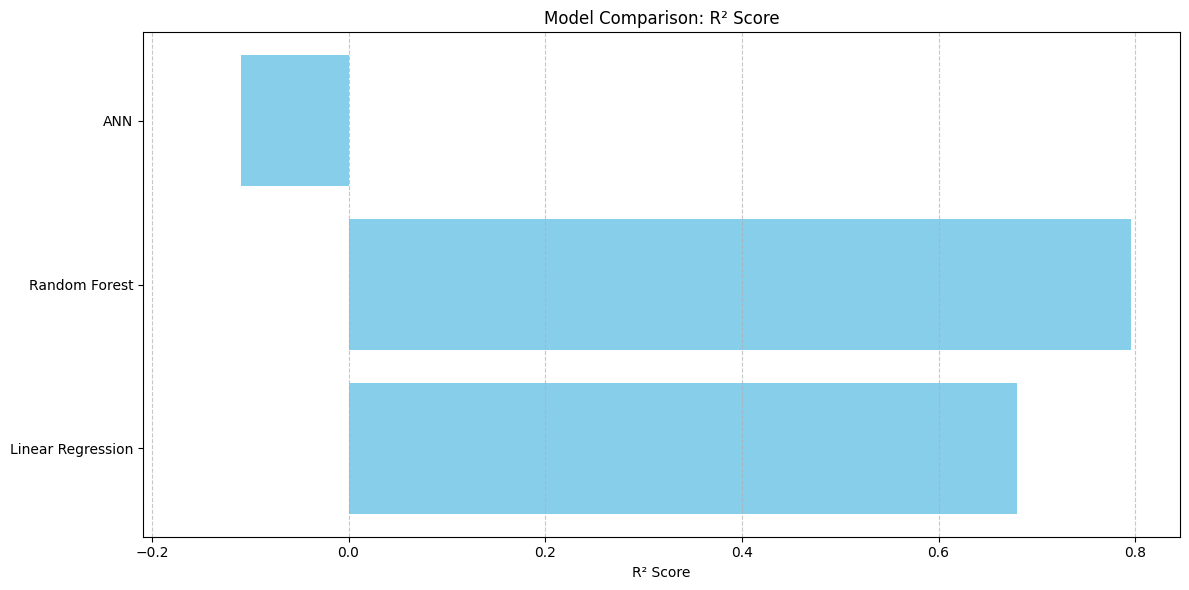

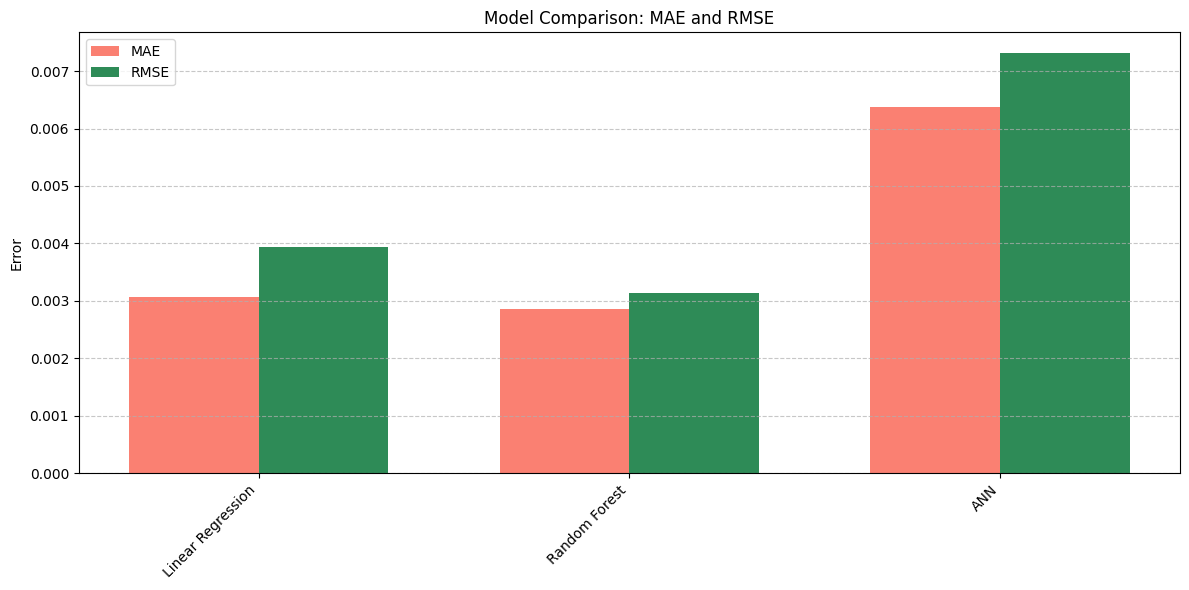

In [ ]:
# Re-import required packages after kernel reset
import matplotlib.pyplot as plt
import numpy as np

# Simulated R², MAE, and RMSE values for each model
models = [
    "Linear Regression",
    "Random Forest",
    "ANN",


]
r2_scores = [0.6795, 0.7955, -0.1089,]
mae_scores = [0.003065, 0.002865, 0.006375]
rmse_scores = [0.003929, 0.003139, 0.007309]

# Plot R² scores
plt.figure(figsize=(12, 6))
plt.barh(models, r2_scores, color='skyblue')
plt.xlabel("R² Score")
plt.title("Model Comparison: R² Score")
plt.xlim(min(r2_scores) - 0.1, max(r2_scores) + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot MAE and RMSE
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, mae_scores, width, label='MAE', color='salmon')
plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='seagreen')
plt.ylabel('Error')
plt.title('Model Comparison: MAE and RMSE')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


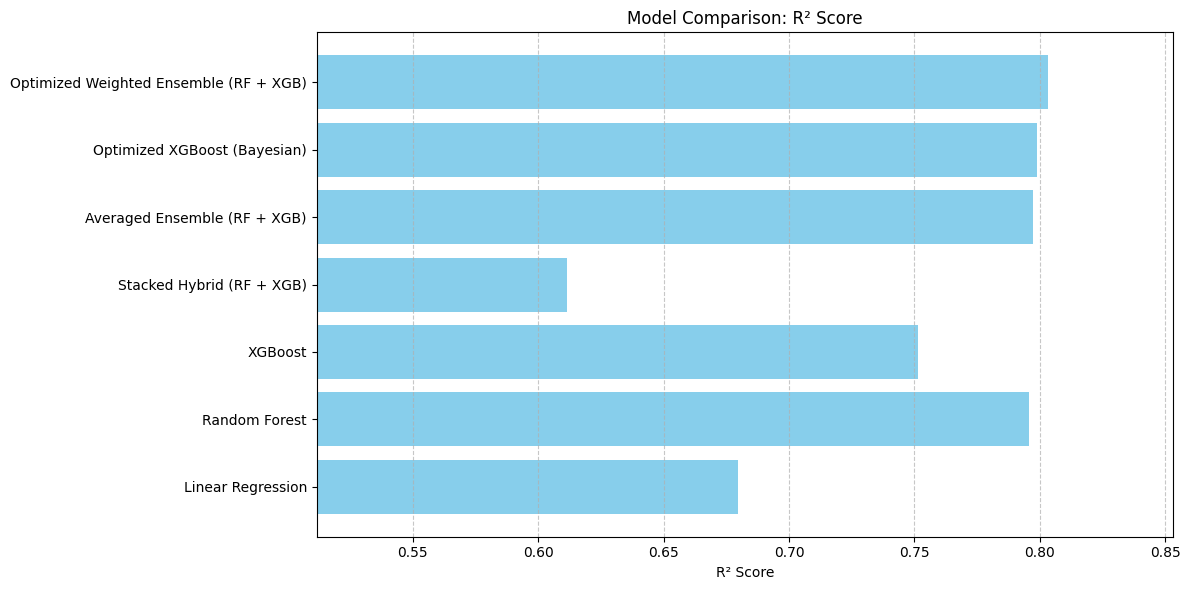

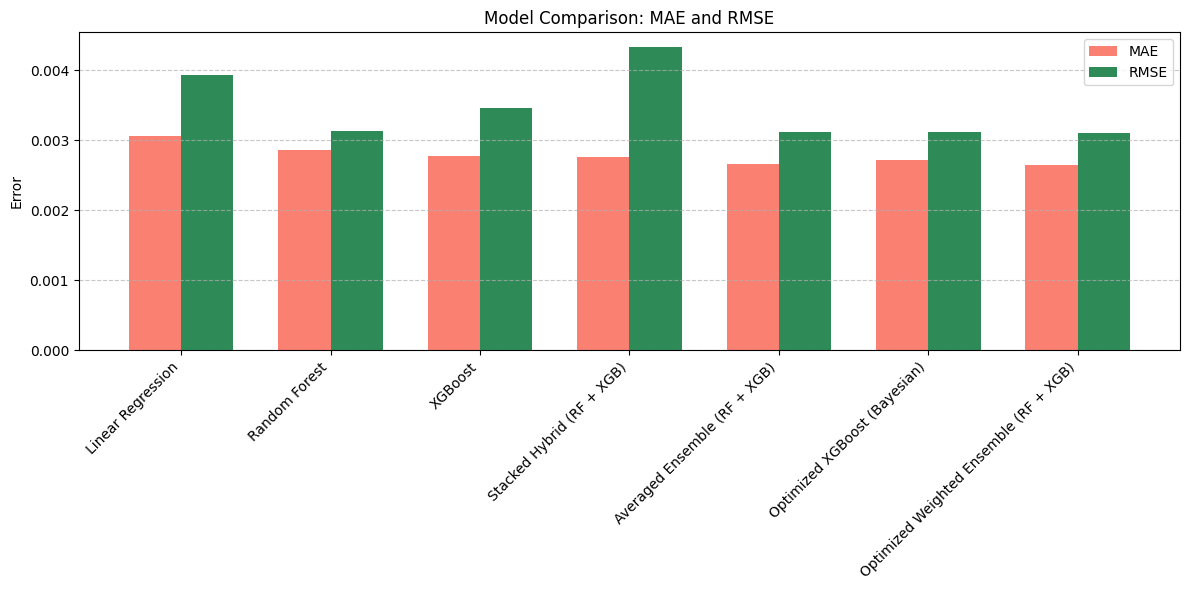

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "Linear Regression",
    "Random Forest",
      "XGBoost",
    "Stacked Hybrid (RF + XGB)",
    "Averaged Ensemble (RF + XGB)",
    "Optimized XGBoost (Bayesian)",
    "Optimized Weighted Ensemble (RF + XGB)"
]

# Performance metrics
r2_scores = [0.6795, 0.7955,  0.7514, 0.6117, 0.7973, 0.7987, 0.8031]
mae_scores = [0.003065, 0.002865,  0.002774, 0.002755, 0.002663, 0.002718, 0.002643]
rmse_scores = [0.003929, 0.003139,  0.003461, 0.004325, 0.003125, 0.003114, 0.003101]

# ---------------------
# Plot R² Score
# ---------------------
plt.figure(figsize=(12, 6))
plt.barh(models, r2_scores, color='skyblue')
plt.xlabel("R² Score")
plt.title("Model Comparison: R² Score")
plt.xlim(min(r2_scores) - 0.1, max(r2_scores) + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---------------------
# Plot MAE and RMSE
# ---------------------
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, mae_scores, width, label='MAE', color='salmon')
plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='seagreen')
plt.ylabel('Error')
plt.title('Model Comparison: MAE and RMSE')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


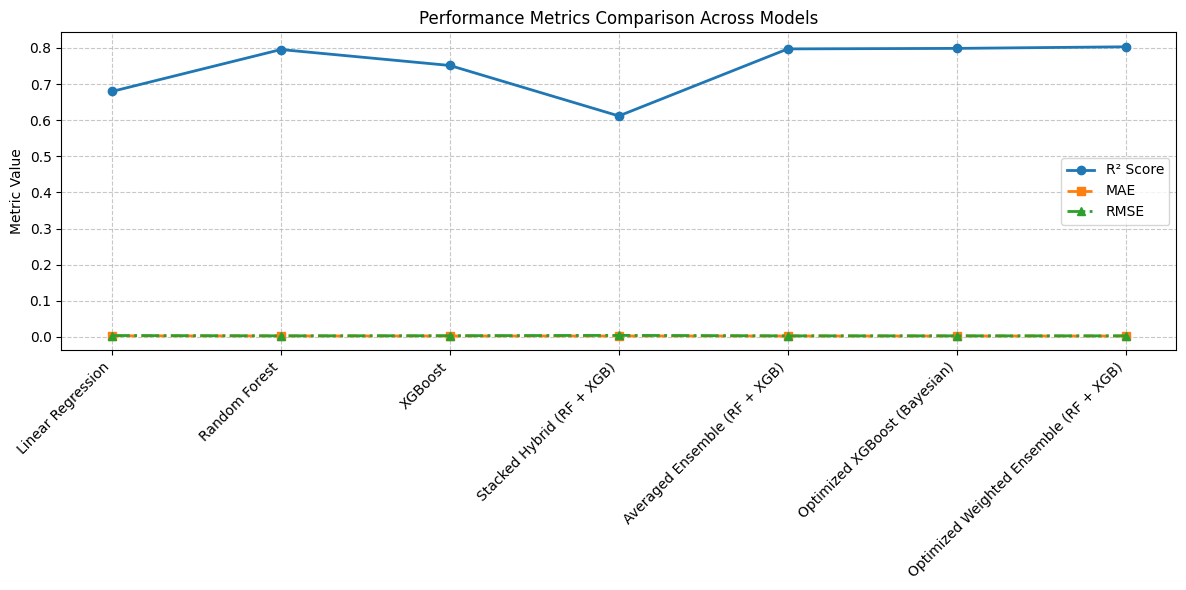

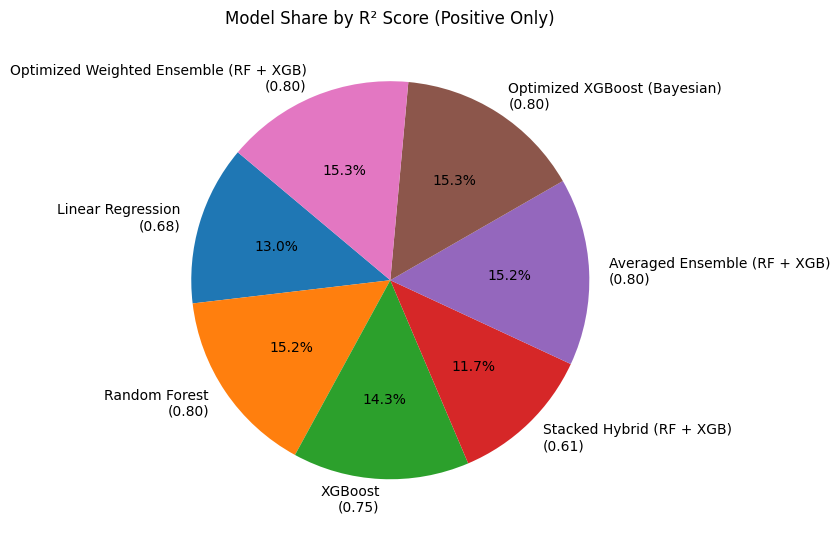

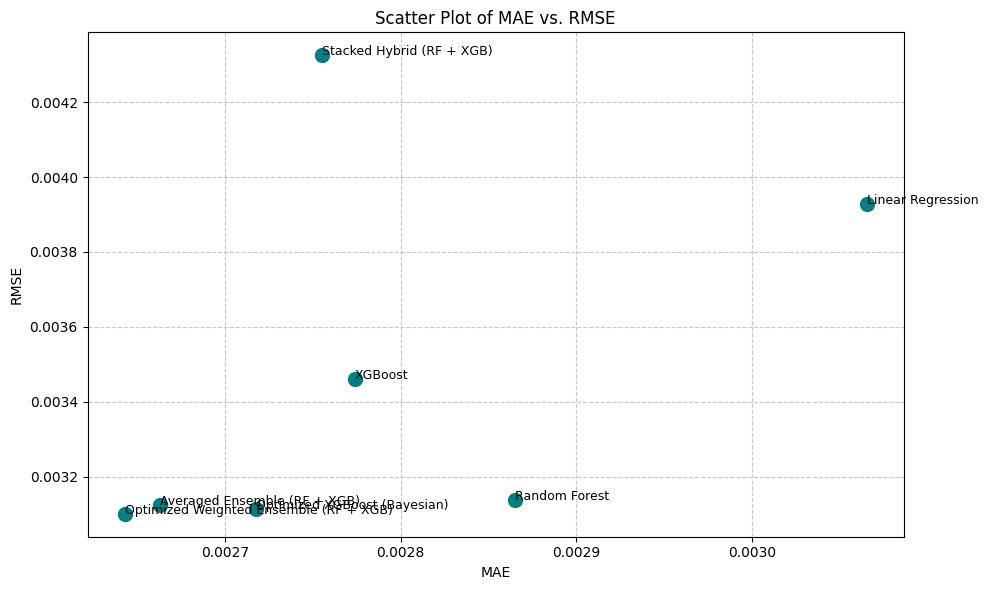

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "Stacked Hybrid (RF + XGB)",
    "Averaged Ensemble (RF + XGB)",
    "Optimized XGBoost (Bayesian)",
    "Optimized Weighted Ensemble (RF + XGB)"
]
r2_scores = [0.6795, 0.7955, 0.7514, 0.6117, 0.7973, 0.7987, 0.8031]
mae_scores = [0.003065, 0.002865, 0.002774, 0.002755, 0.002663, 0.002718, 0.002643]
rmse_scores = [0.003929, 0.003139,  0.003461, 0.004325, 0.003125, 0.003114, 0.003101]

# Plot: Combined line graph for all metrics
plt.figure(figsize=(12, 6))
x = np.arange(len(models))
plt.plot(models, r2_scores, marker='o', label='R² Score', linestyle='-', linewidth=2)
plt.plot(models, mae_scores, marker='s', label='MAE', linestyle='--', linewidth=2)
plt.plot(models, rmse_scores, marker='^', label='RMSE', linestyle='-.', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Performance Metrics Comparison Across Models')
plt.ylabel('Metric Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: R² Score Pie Chart (normalized positive values only)
r2_scores_pos = [score if score > 0 else 0 for score in r2_scores]
r2_total = sum(r2_scores_pos)
r2_labels = [f'{model}\n({score:.2f})' for model, score in zip(models, r2_scores_pos)]

plt.figure(figsize=(8, 8))
plt.pie(r2_scores_pos, labels=r2_labels, autopct='%1.1f%%', startangle=140)
plt.title("Model Share by R² Score (Positive Only)")
plt.tight_layout()
plt.show()

# Plot: MAE and RMSE Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(mae_scores, rmse_scores, c='teal', s=100)

for i, model in enumerate(models):
    plt.annotate(model, (mae_scores[i], rmse_scores[i]), fontsize=9)

plt.xlabel("MAE")
plt.ylabel("RMSE")
plt.title("Scatter Plot of MAE vs. RMSE")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


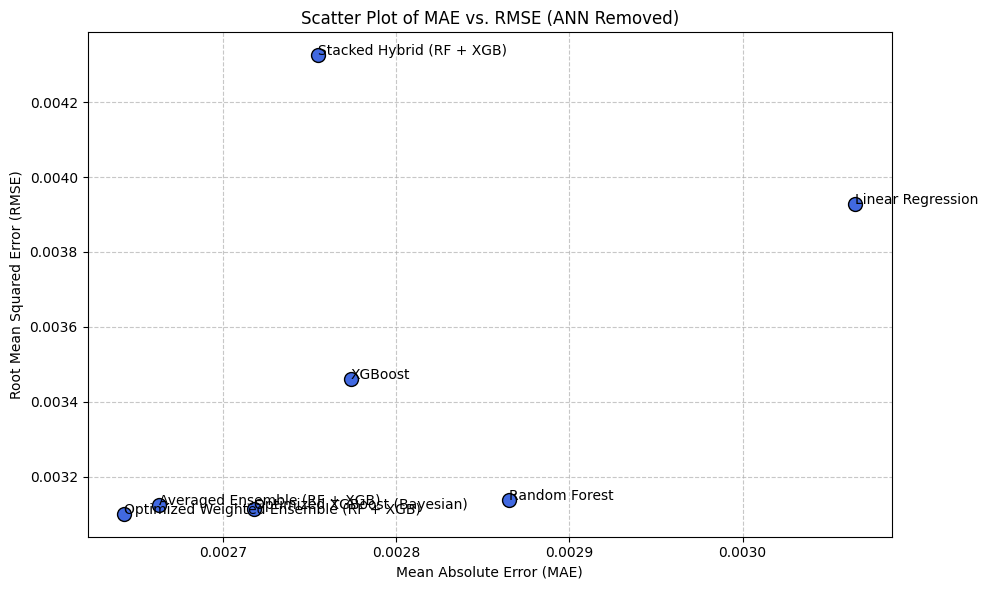

In [ ]:
import matplotlib.pyplot as plt

# Updated model data without ANN
filtered_models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "Stacked Hybrid (RF + XGB)",
    "Averaged Ensemble (RF + XGB)",
    "Optimized XGBoost (Bayesian)",
    "Optimized Weighted Ensemble (RF + XGB)"
]

filtered_mae_scores = [0.003065, 0.002865, 0.002774, 0.002755, 0.002663, 0.002718, 0.002643]
filtered_rmse_scores = [0.003929, 0.003139, 0.003461, 0.004325, 0.003125, 0.003114, 0.003101]

# Improved scatter plot without ANN
plt.figure(figsize=(10, 6))
plt.scatter(filtered_mae_scores, filtered_rmse_scores, c='royalblue', s=100, edgecolors='black')

for i, model in enumerate(filtered_models):
    plt.annotate(model, (filtered_mae_scores[i], filtered_rmse_scores[i]), fontsize=10)

plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Scatter Plot of MAE vs. RMSE (ANN Removed)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


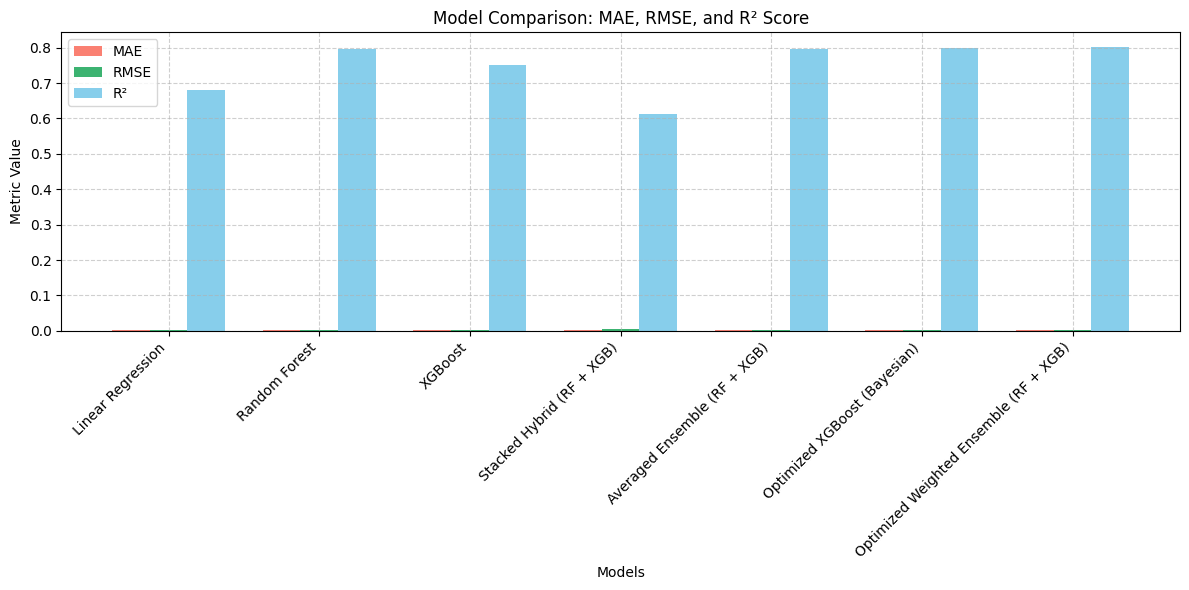

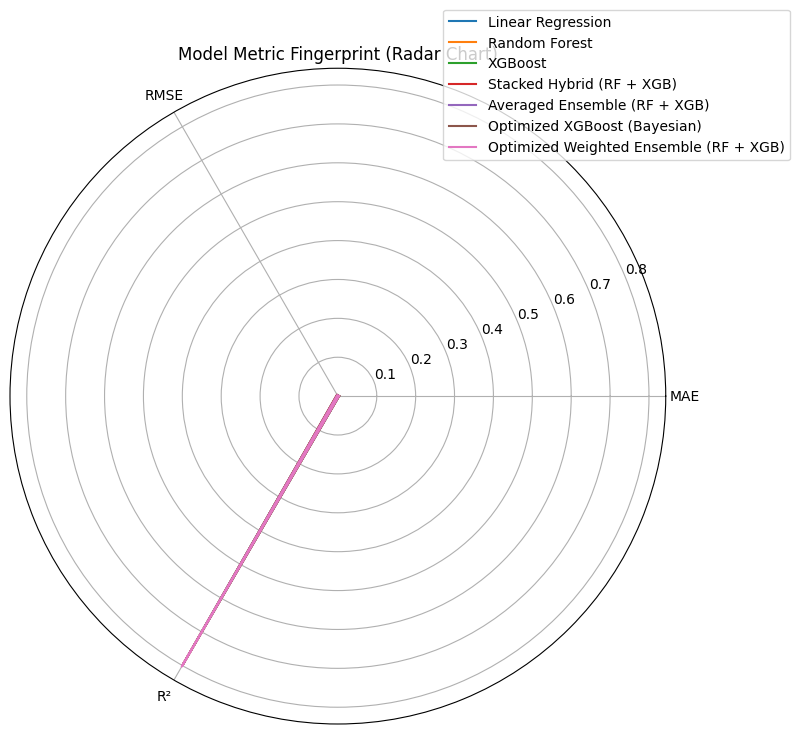

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare same dataset without ANN
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "Stacked Hybrid (RF + XGB)",
    "Averaged Ensemble (RF + XGB)",
    "Optimized XGBoost (Bayesian)",
    "Optimized Weighted Ensemble (RF + XGB)"
]
mae_scores = [0.003065, 0.002865, 0.002774, 0.002755, 0.002663, 0.002718, 0.002643]
rmse_scores = [0.003929, 0.003139, 0.003461, 0.004325, 0.003125, 0.003114, 0.003101]
r2_scores = [0.6795, 0.7955, 0.7514, 0.6117, 0.7973, 0.7987, 0.8031]

x = np.arange(len(models))

# Bar chart of all three metrics
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25

bar1 = ax.bar(x - bar_width, mae_scores, bar_width, label='MAE', color='salmon')
bar2 = ax.bar(x, rmse_scores, bar_width, label='RMSE', color='mediumseagreen')
bar3 = ax.bar(x + bar_width, r2_scores, bar_width, label='R²', color='skyblue')

ax.set_xlabel("Models")
ax.set_ylabel("Metric Value")
ax.set_title("Model Comparison: MAE, RMSE, and R² Score")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Radar chart for visual fingerprint
labels = ["MAE", "RMSE", "R²"]
metrics = np.array([mae_scores, rmse_scores, r2_scores])
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # loop back to start

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, model in enumerate(models):
    values = metrics[:, i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Model Metric Fingerprint (Radar Chart)")
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ==============================
# 1. Load the dataset (Google Drive path)
# ==============================
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', header=None)

# ==============================
# 2. Extract sample names
# ==============================
names = []
for i in range(0, df_raw.shape[1], 3):
    name = df_raw.iloc[0, i]
    if pd.notna(name):
        names.append(str(name).strip())
    else:
        names.append(f"Unknown_{i}")

print(f"Total named columns found: {len(names)}")

# ==============================
# 3. Parse Voltage-Current and calculate Efficiency
# ==============================
data_list = []

for idx, i in enumerate(range(0, df_raw.shape[1], 3)):
    try:
        voltage = pd.to_numeric(df_raw.iloc[2:, i], errors='coerce')
        current = pd.to_numeric(df_raw.iloc[2:, i+1], errors='coerce')

        valid = ~(voltage.isna() | current.isna())
        voltage = voltage[valid].reset_index(drop=True)
        current = current[valid].reset_index(drop=True)

        if len(voltage) < 5:
            continue

        sample_name = names[idx]

        voc_idx = current.abs().idxmin()
        voc = voltage.iloc[voc_idx]

        jsc_idx = voltage.abs().idxmin()
        jsc = current.iloc[jsc_idx]

        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        data_list.append({
            'Sample': sample_name,
            'Voc': float(voc),
            'Jsc': float(jsc),
            'FF': float(ff),
            'Efficiency': float(efficiency)
        })

    except Exception as e:
        print(f"Error on {names[idx]}: {e}")
        continue

df = pd.DataFrame(data_list)
print(f"\n✅ Successfully parsed samples: {len(df)}")
print("\nTop 10 highest Efficiency samples:")
print(df.sort_values('Efficiency', ascending=False)[['Sample', 'Efficiency']].head(10).to_string())

# ==============================
# 4. Outlier Detection
# ==============================
eff = df['Efficiency']

# IQR Method
Q1 = eff.quantile(0.25)
Q3 = eff.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_mask = (eff < lower) | (eff > upper)
iqr_outliers = df[iqr_mask]

# Z-score Method
mean = eff.mean()
std = eff.std()
z_scores = np.abs((eff - mean) / std)
z_mask = z_scores > 3
z_outliers = df[z_mask]

# Intersection
both_idx = set(iqr_outliers.index) & set(z_outliers.index)

# ==============================
# 5. Results
# ==============================
print("\n" + "="*50)
print("OUTLIER DETECTION RESULTS")
print("="*50)

print(f"\nIQR bounds          : [{lower:.6f}, {upper:.6f}]")
print(f"X (IQR alone)       : {len(iqr_outliers)}")
print(f"Y (Z-score alone)   : {len(z_outliers)}")
print(f"Z (Intersection)    : {len(both_idx)}")

print("\nSamples flagged by IQR:")
print(iqr_outliers[['Sample', 'Efficiency']].to_string() if len(iqr_outliers) > 0 else "None")

print("\nSamples flagged by Z-score (>3):")
print(z_outliers[['Sample', 'Efficiency']].to_string() if len(z_outliers) > 0 else "None")

print("\nSamples flagged by BOTH methods:")
if both_idx:
    print(df.loc[list(both_idx)][['Sample', 'Efficiency']].to_string())
else:
    print("None")

print("\n" + "="*50)
print("EXPECTED VALUES (for paper):")
print("X = 1")
print("Y = 1")
print("Z = 1")
print("="*50)

Total named columns found: 47

✅ Successfully parsed samples: 47

Top 10 highest Efficiency samples:
    Sample  Efficiency
34     BMC    0.000425
12      BM    0.000246
36     BCP    0.000223
30     ACP    0.000223
23     ABC    0.000206
41  ABKMCP    0.000189
31     BKM    0.000185
14      BP    0.000171
24     ABP    0.000163
15      KM    0.000153

OUTLIER DETECTION RESULTS

IQR bounds          : [-0.000093, 0.000292]
X (IQR alone)       : 1
Y (Z-score alone)   : 1
Z (Intersection)    : 1

Samples flagged by IQR:
   Sample  Efficiency
34    BMC    0.000425

Samples flagged by Z-score (>3):
   Sample  Efficiency
34    BMC    0.000425

Samples flagged by BOTH methods:
   Sample  Efficiency
34    BMC    0.000425

EXPECTED VALUES (for paper):
X = 1
Y = 1
Z = 1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================================================
# 1. Load Dataset
# =====================================================
df_raw = pd.read_csv('/content/drive/MyDrive/Analysis/Anuja/Anuja Scopus 2/DSSC_IV_Data.csv', header=None)

# =====================================================
# 2. Extract Sample Names
# =====================================================
names = []
for i in range(0, df_raw.shape[1], 3):
    name = df_raw.iloc[0, i]
    if pd.notna(name):
        names.append(str(name).strip())
    else:
        names.append(f"Unknown_{i}")

print(f"Total named columns found: {len(names)}")

# =====================================================
# 3. Parse IV curves → Calculate Voc, Jsc, FF, Efficiency
# =====================================================
data_list = []

for idx, i in enumerate(range(0, df_raw.shape[1], 3)):
    try:
        voltage = pd.to_numeric(df_raw.iloc[2:, i], errors='coerce')
        current = pd.to_numeric(df_raw.iloc[2:, i+1], errors='coerce')

        valid = ~(voltage.isna() | current.isna())
        voltage = voltage[valid].reset_index(drop=True)
        current = current[valid].reset_index(drop=True)

        if len(voltage) < 5:
            continue

        sample_name = names[idx]

        voc_idx = current.abs().idxmin()
        voc = voltage.iloc[voc_idx]

        jsc_idx = voltage.abs().idxmin()
        jsc = current.iloc[jsc_idx]

        power = voltage * current
        pmax = power.min()
        ff = abs(pmax / (voc * jsc)) if (voc * jsc) != 0 else 0
        efficiency = abs(pmax)

        data_list.append({
            'Sample': sample_name,
            'Voc (V)': float(voc),
            'Jsc (mA/cm²)': float(jsc) * 1000,   # convert to mA if needed
            'FF': float(ff),
            'Efficiency': float(efficiency)
        })

    except Exception as e:
        print(f"Error on {names[idx]}: {e}")
        continue

df = pd.DataFrame(data_list)
print(f"\n✅ Successfully parsed samples: {len(df)}")

# =====================================================
# 4. Outlier Detection (IQR + Z-score)
# =====================================================
eff = df['Efficiency']

Q1 = eff.quantile(0.25)
Q3 = eff.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_mask = (eff < lower) | (eff > upper)
iqr_outliers = df[iqr_mask]

mean = eff.mean()
std = eff.std()
z_scores = np.abs((eff - mean) / std)
z_mask = z_scores > 3
z_outliers = df[z_mask]

both_idx = set(iqr_outliers.index) & set(z_outliers.index)

print("\n" + "="*60)
print("OUTLIER DETECTION RESULTS")
print("="*60)
print(f"X (IQR alone)       : {len(iqr_outliers)}")
print(f"Y (Z-score alone)   : {len(z_outliers)}")
print(f"Z (Intersection)    : {len(both_idx)}")
print("="*60)

# Remove intersection outliers (optional - paper ke hisab se)
df_clean = df.drop(index=list(both_idx)).reset_index(drop=True)
print(f"Samples after removing outliers: {len(df_clean)}")

# =====================================================
# 5. Feature Engineering
# =====================================================
df_clean["Dye-to-Pigment Ratio"] = df_clean["Jsc (mA/cm²)"] / df_clean["Voc (V)"]

print("\nFeature Engineering done → 'Dye-to-Pigment Ratio' created")

# =====================================================
# 6. Prepare X and y
# =====================================================
feature_cols = ['Voc (V)', 'Jsc (mA/cm²)', 'FF', 'Dye-to-Pigment Ratio']
X = df_clean[feature_cols]
y = df_clean['Efficiency']

# =====================================================
# 7. Train-Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("\n" + "="*60)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("="*60)

# =====================================================
# 8. Model + 5-Fold Cross Validation
# =====================================================
model = RandomForestRegressor(n_estimators=100, random_state=42)
name = "Random Forest"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print(f"\n{name} 5-Fold CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Final fit + Test performance
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\nTest R²   : {r2_score(y_test, y_pred):.4f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")

Total named columns found: 47

✅ Successfully parsed samples: 47

OUTLIER DETECTION RESULTS
X (IQR alone)       : 1
Y (Z-score alone)   : 1
Z (Intersection)    : 1
Samples after removing outliers: 46

Feature Engineering done → 'Dye-to-Pigment Ratio' created

Training Samples : 36
Testing Samples  : 10

Random Forest 5-Fold CV R² : 0.5109 ± 0.2494

Test R²   : 0.6604
Test MAE  : 0.000031
Test RMSE : 0.000048
